# STDFT-LRP Summary Plots

This notebook loads per-model `stdftlrp_beat_agg.csv` files and produces: 
1) single-model lead-importance summaries,
2) grouped summaries across model families (track / preprocessing / loss).


In [15]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Resolve repo root (look for configs/analysis/embeddings_probe_runs.toml)
root = Path.cwd().resolve()
marker = Path('configs/analysis/embeddings_probe_runs.toml')
if not (root / marker).exists():
    for parent in root.parents:
        if (parent / marker).exists():
            root = parent
            break
print('Repo root:', root)

# Add src to path for run_specs import
src_root = root / 'src'
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

OUT_DIR = root / 'analysis/embeddings_probe'
RUNS_DIR = OUT_DIR / 'runs'

# ---- Switch this to compare leads ----
LEAD_TAG = 'lead_7'  # e.g. 'lead_1' (Lead II), 'lead_7' (V2)
XAI_SUMMARY_DIR = OUT_DIR / 'xai_summary' / LEAD_TAG
XAI_SUMMARY_DIR.mkdir(parents=True, exist_ok=True)
out_dir = XAI_SUMMARY_DIR
print('Using lead tag:', LEAD_TAG)
print('Summary output dir:', out_dir)


Repo root: /home/flo178/projects/master-thesis/ecg-chagas-embeddings
Using lead tag: lead_7
Summary output dir: /home/flo178/projects/master-thesis/ecg-chagas-embeddings/analysis/embeddings_probe/xai_summary/lead_7


In [16]:
# Discover available per-model CSVs for selected lead
RUNS_DIR = root / 'analysis' / 'embeddings_probe' / 'runs'

# Preferred: lead-specific path
csv_paths = sorted(RUNS_DIR.glob(f'*/xai/{LEAD_TAG}/stdftlrp_beat_agg.csv'))

# Fallbacks (legacy)
if not csv_paths and LEAD_TAG == 'lead_1':
    csv_paths = sorted(RUNS_DIR.glob('*/xai/stdftlrp_beat_agg.csv'))
if not csv_paths and LEAD_TAG == 'lead_1':
    csv_paths = sorted(RUNS_DIR.glob('*/stdftlrp_beat_agg.csv'))

print('Found', len(csv_paths), f'CSV files for {LEAD_TAG}')


def infer_run_id(path: Path) -> str:
    parts = list(path.parts)
    if 'runs' in parts:
        i = parts.index('runs')
        if i + 1 < len(parts):
            return parts[i + 1]
    return path.parent.name

# Map run_id -> csv path
run_to_csv = {infer_run_id(p): p for p in csv_paths}

# Pick one model to inspect
run_id = sorted(run_to_csv.keys())[0] if run_to_csv else None
print('Example run_id:', run_id)


Found 24 CSV files for lead_7
Example run_id: t1-exp01-bp-bce


In [17]:
# Overlap between probe set and RRA robust sets
import pandas as pd

probe_path = OUT_DIR / 'probe_index.csv'
rra_path = OUT_DIR / 'ranking_agreement' / 'test' / 'sample_rra_consensus.csv'

probe = pd.read_csv(probe_path)
rra = pd.read_csv(rra_path)

probe_ids = set(probe['exam_id'].astype(str))
robust_pos = rra[rra['rra_rank_pos'].notna()]
robust_neg = rra[rra['rra_rank_neg'].notna()]

robust_pos_ids = set(robust_pos['exam_id'].astype(str))
robust_neg_ids = set(robust_neg['exam_id'].astype(str))

n_probe = len(probe_ids)

summary = pd.DataFrame([
    {
        'group': 'robust_pos',
        'n_total': len(robust_pos_ids),
        'n_in_probe': len(robust_pos_ids & probe_ids),
        'pct_in_probe': 100.0 * len(robust_pos_ids & probe_ids) / max(1, len(robust_pos_ids)),
    },
    {
        'group': 'robust_neg',
        'n_total': len(robust_neg_ids),
        'n_in_probe': len(robust_neg_ids & probe_ids),
        'pct_in_probe': 100.0 * len(robust_neg_ids & probe_ids) / max(1, len(robust_neg_ids)),
    },
    {
        'group': 'probe_total',
        'n_total': n_probe,
        'n_in_probe': n_probe,
        'pct_in_probe': 100.0,
    },
])

summary


/tmp/ipykernel_436309/1598349299.py:8: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  rra = pd.read_csv(rra_path)


,group,n_total,n_in_probe,pct_in_probe
0,robust_pos,7411,605,8.163541
1,robust_neg,11456,999,8.720321
2,probe_total,4893,4893,100.000000


In [18]:
# Load one model CSV
assert run_id is not None, 'No stdftlrp_beat_agg.csv files found'
assert run_id in run_to_csv, f'run_id {run_id} not in discovered CSVs'

df = pd.read_csv(run_to_csv[run_id])
print(df.shape)
df[['source','chagas']].value_counts()


(4820, 83)


source    chagas
CODE15    0         1621
PTBXL     0         1596
CODE15    1         1296
SAMITROP  1          307
Name: count, dtype: int64

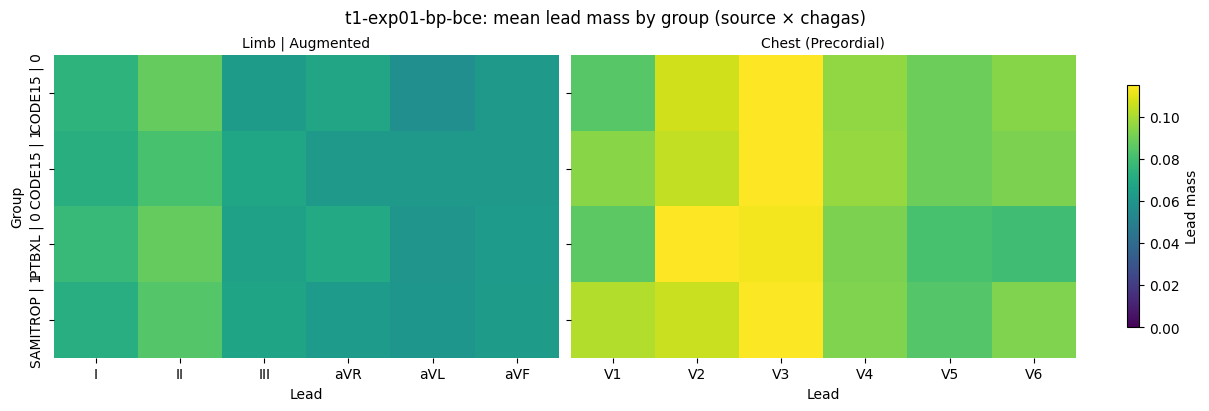

In [19]:
# Single-model lead-importance heatmap by source x chagas
lead_cols = [c for c in df.columns if c.startswith('p_lead_')]
lead_order = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']

df['source'] = df['source'].astype(str).str.upper().str.replace('-', '', regex=False)
df['group'] = df['source'].astype(str) + ' | ' + df['chagas'].astype(str)
group_means = df.groupby('group')[lead_cols].mean().reindex(sorted(df['group'].unique()))
group_means.columns = lead_order

# Split into lead groups so labels are clean without custom overlays
lead_groups = {
    'Limb | Augmented': ['I','II','III','aVR','aVL','aVF'],
    'Chest (Precordial)': ['V1','V2','V3','V4','V5','V6'],
}

vmax = float(np.quantile(group_means.to_numpy().ravel(), 0.95))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True, constrained_layout=True)
for ax, (gname, cols) in zip(axes, lead_groups.items()):
    sub = group_means[cols]
    sns.heatmap(sub, ax=ax, cmap='viridis', vmin=0, vmax=vmax, cbar=False)
    ax.set_title(gname, fontsize=10)
    ax.set_xlabel('Lead')
    if ax is axes[0]:
        ax.set_ylabel('Group')
    else:
        ax.set_ylabel('')

# single shared colorbar
mappable = axes[0].collections[0]
fig.colorbar(mappable, ax=axes, location='right', shrink=0.8, label='Lead mass')
fig.suptitle(f'{run_id}: mean lead mass by group (source × chagas)', fontsize=12)
plt.show()


/tmp/ipykernel_436309/212001176.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('RdBu_r')


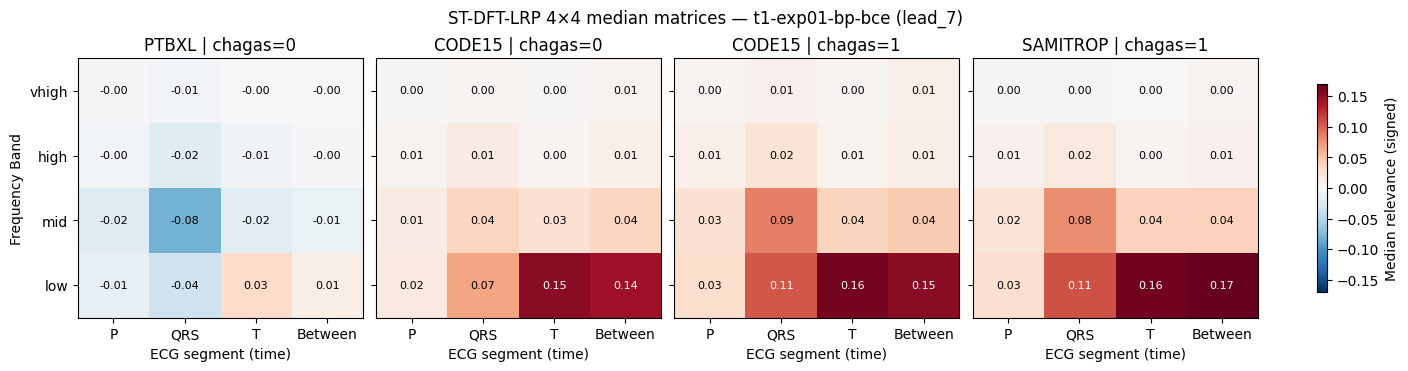

/tmp/ipykernel_436309/212001176.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('RdBu_r')


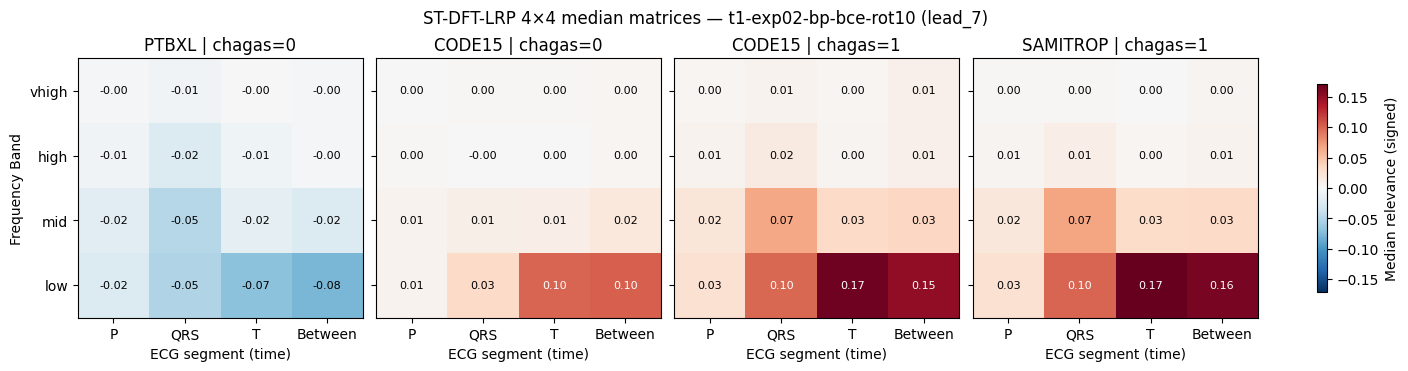

/tmp/ipykernel_436309/212001176.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('RdBu_r')


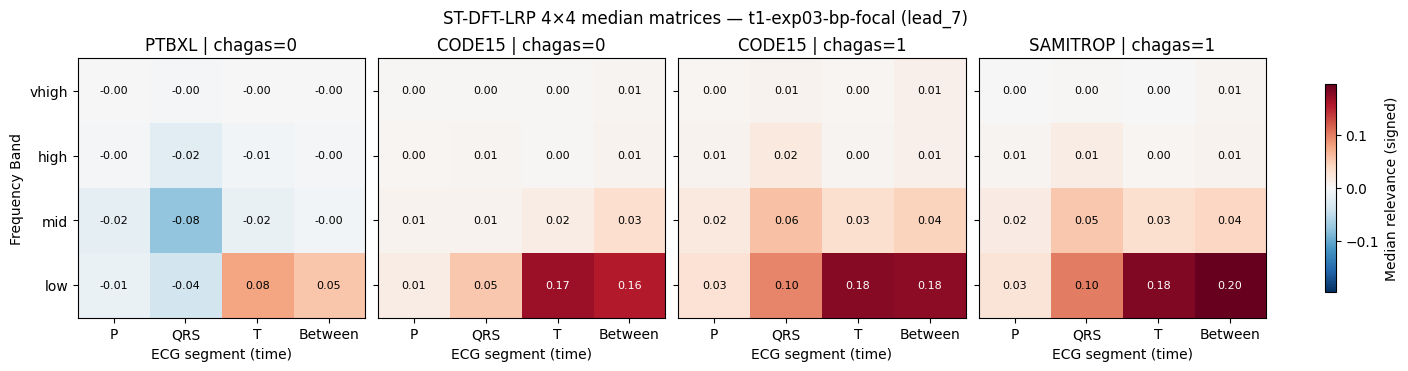

/tmp/ipykernel_436309/212001176.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('RdBu_r')


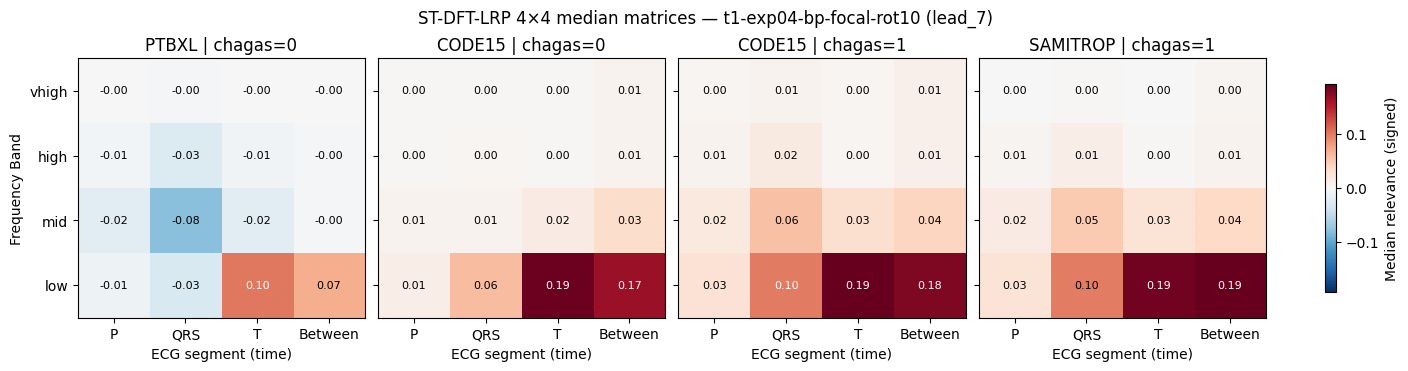

/tmp/ipykernel_436309/212001176.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('RdBu_r')


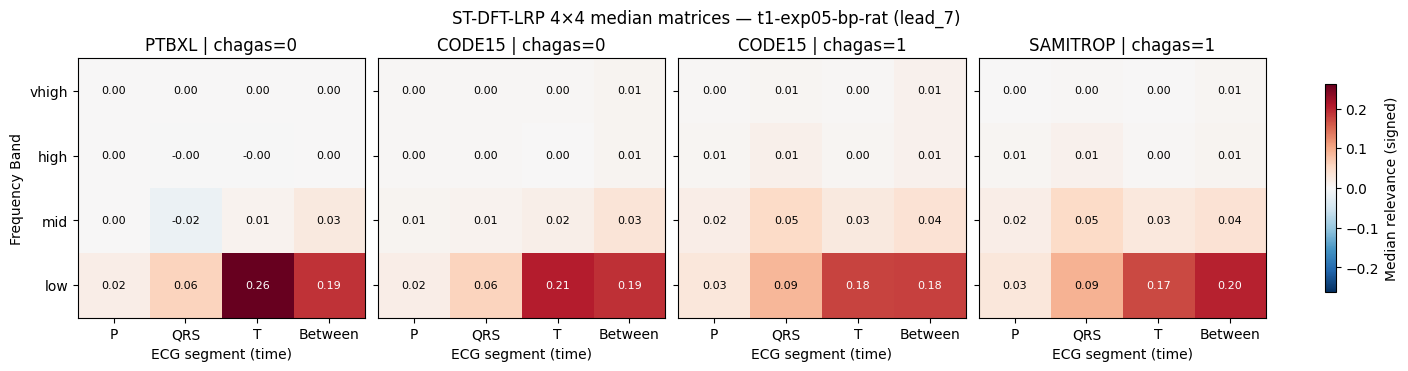

/tmp/ipykernel_436309/212001176.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('RdBu_r')


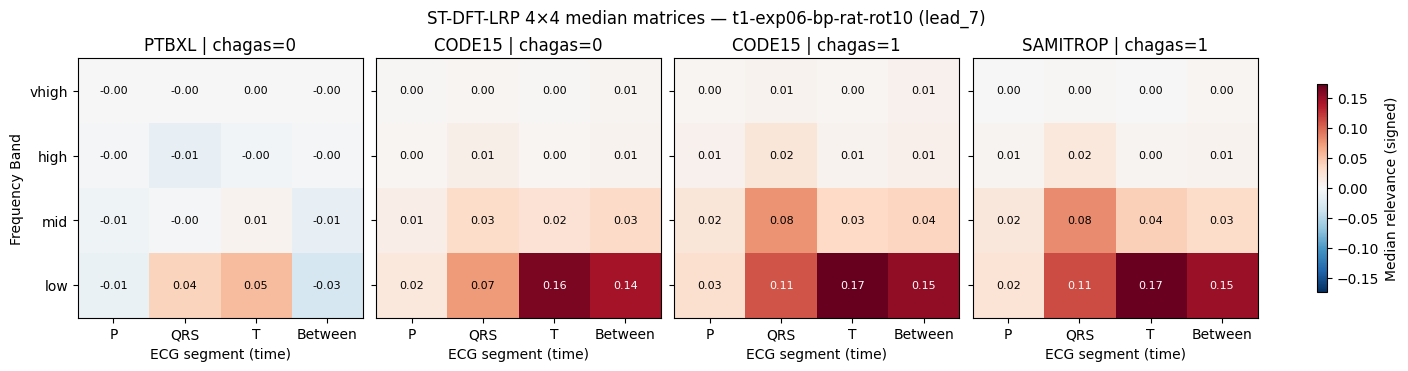

/tmp/ipykernel_436309/212001176.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('RdBu_r')


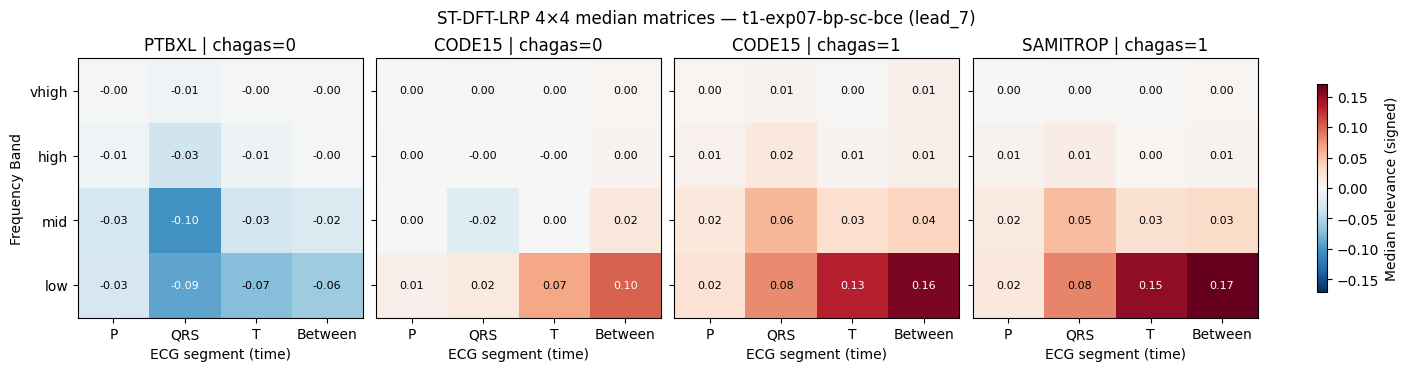

/tmp/ipykernel_436309/212001176.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('RdBu_r')


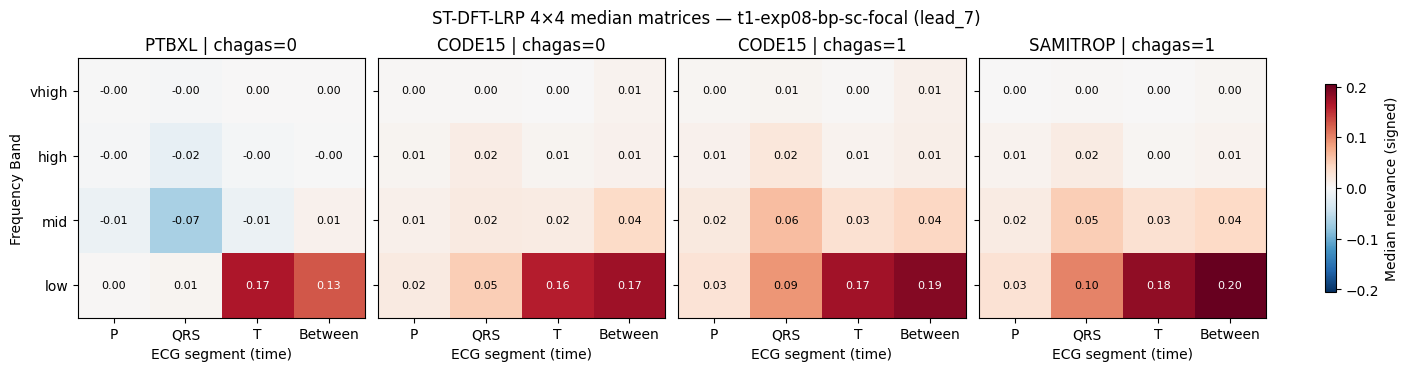

/tmp/ipykernel_436309/212001176.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('RdBu_r')


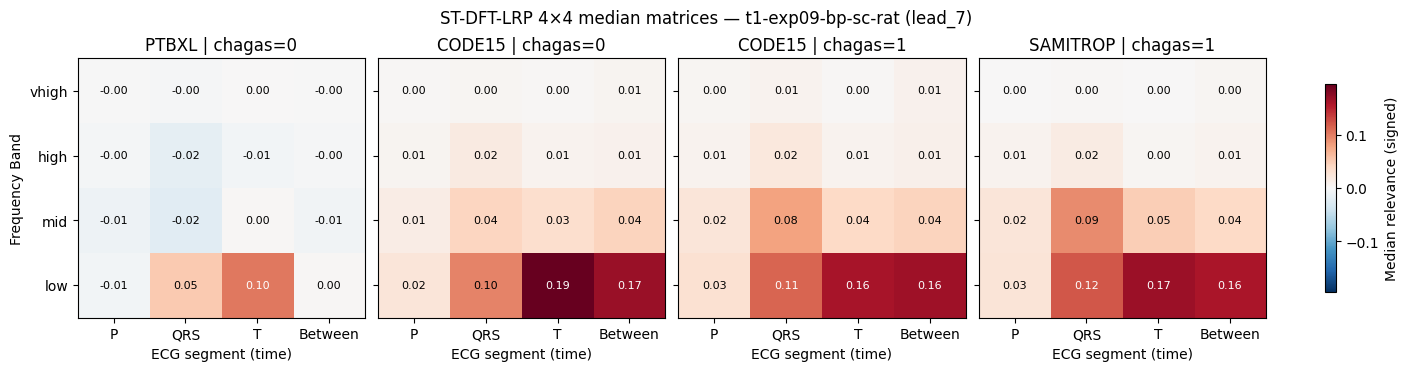

/tmp/ipykernel_436309/212001176.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('RdBu_r')


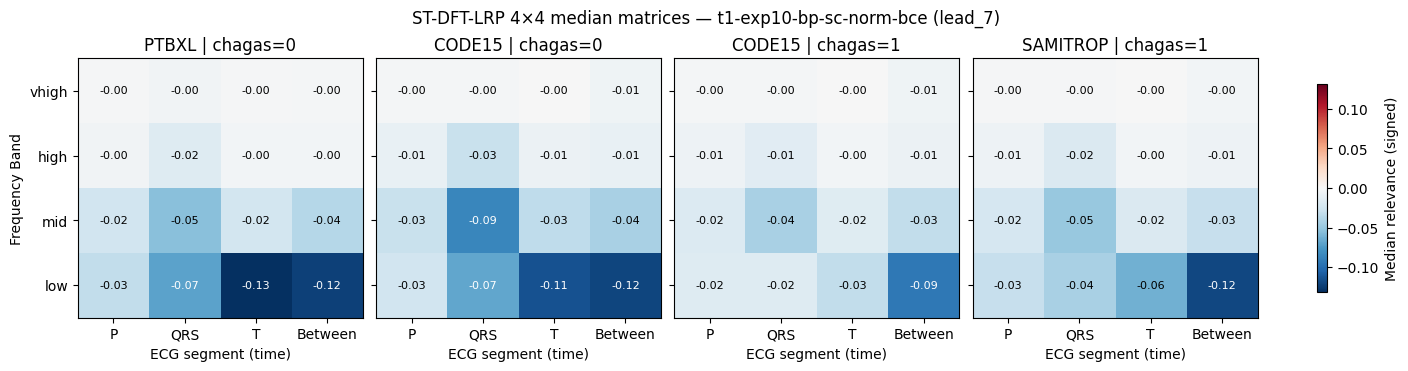

/tmp/ipykernel_436309/212001176.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('RdBu_r')


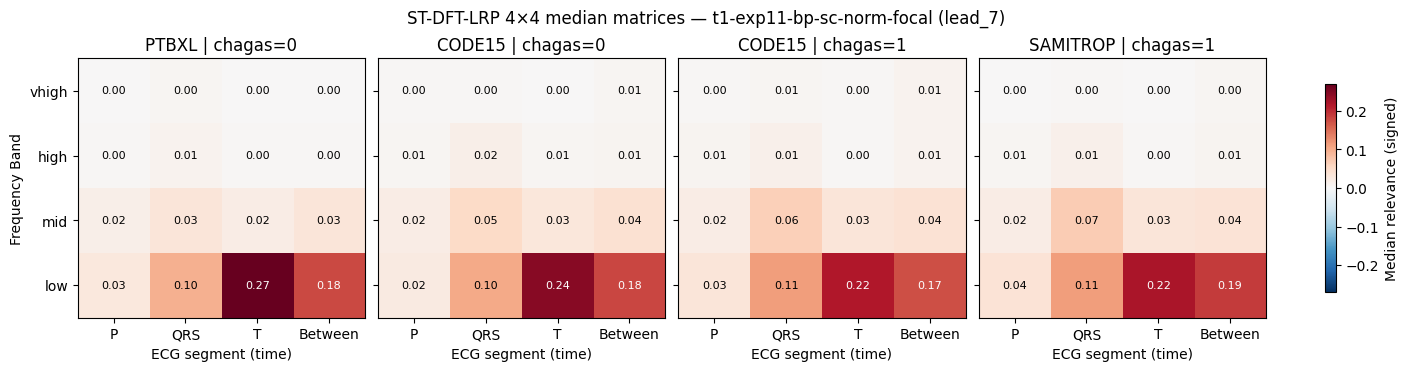

/tmp/ipykernel_436309/212001176.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('RdBu_r')


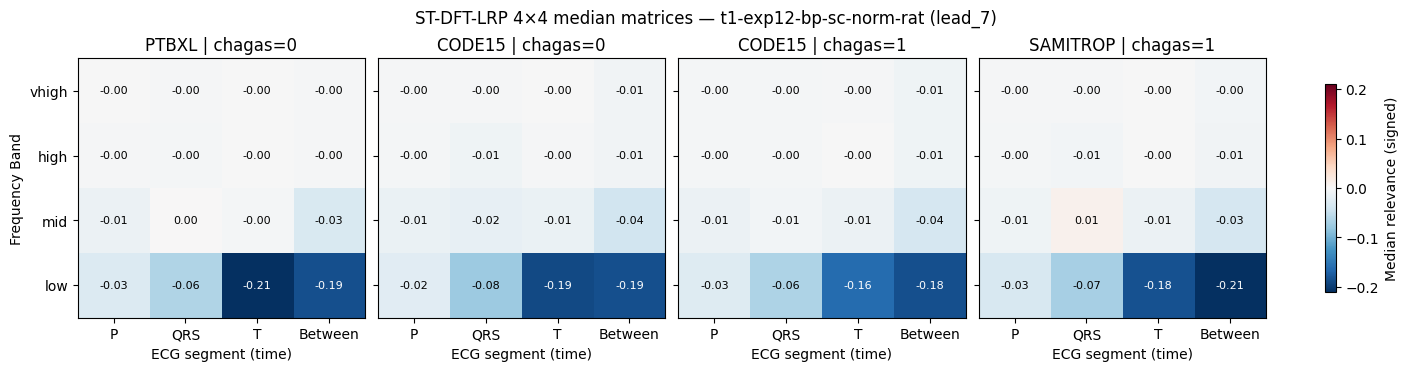

/tmp/ipykernel_436309/212001176.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('RdBu_r')


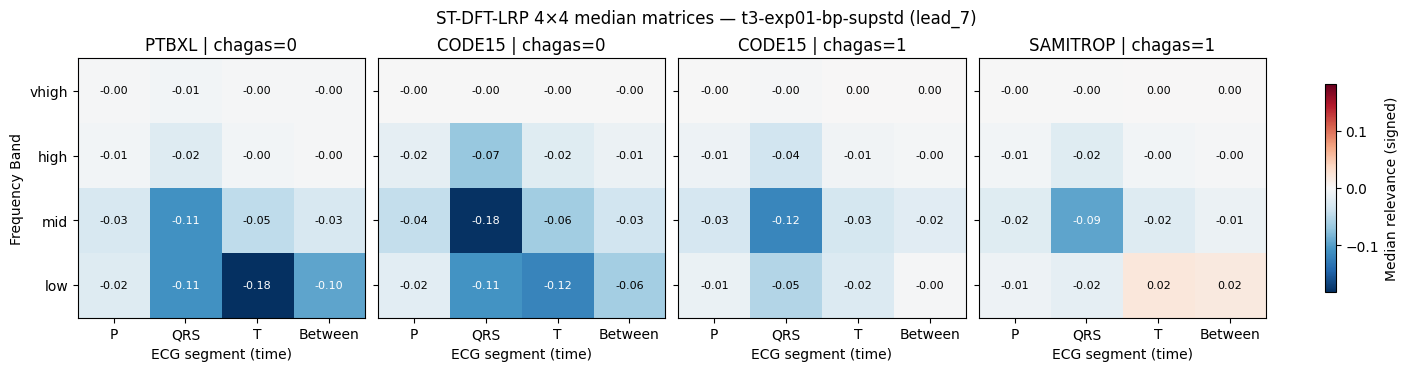

/tmp/ipykernel_436309/212001176.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('RdBu_r')


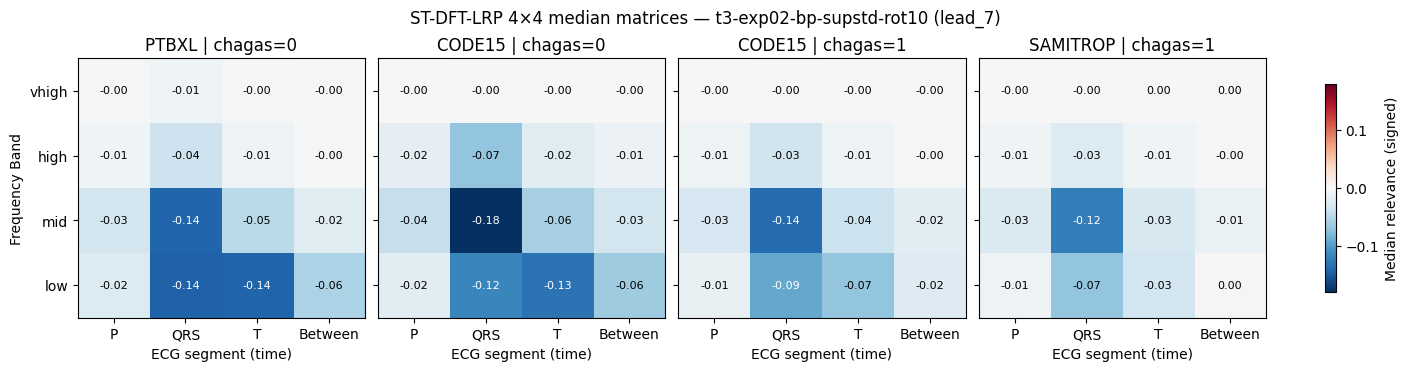

/tmp/ipykernel_436309/212001176.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('RdBu_r')


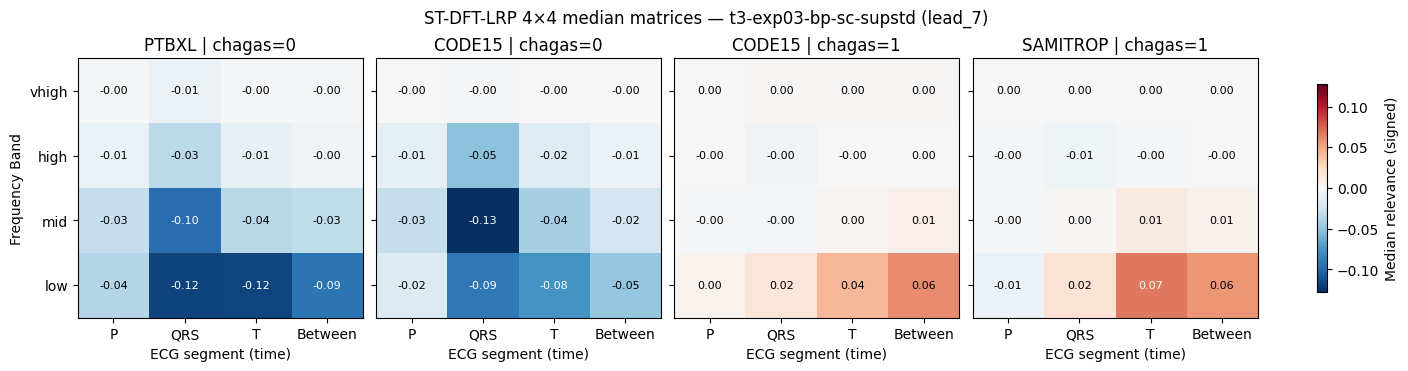

/tmp/ipykernel_436309/212001176.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('RdBu_r')


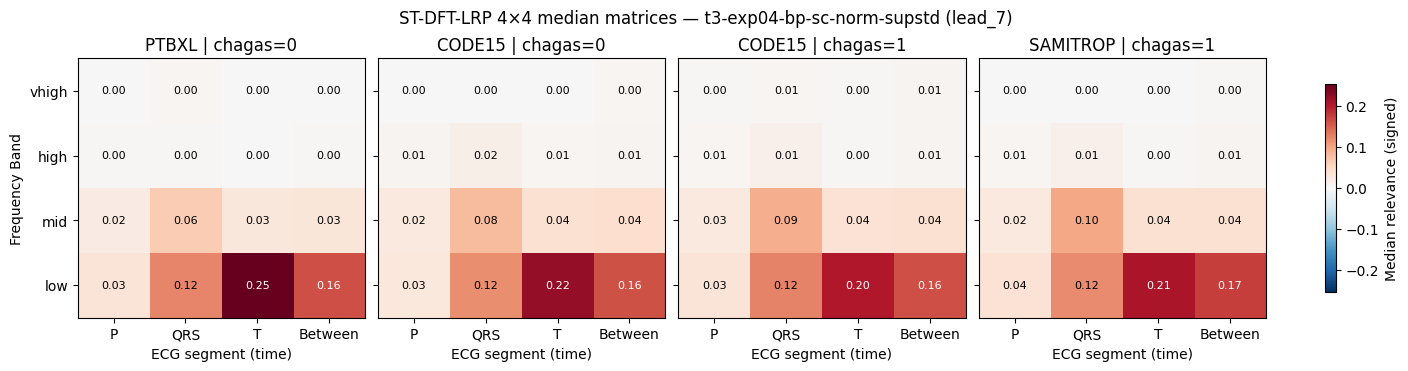

/tmp/ipykernel_436309/212001176.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('RdBu_r')


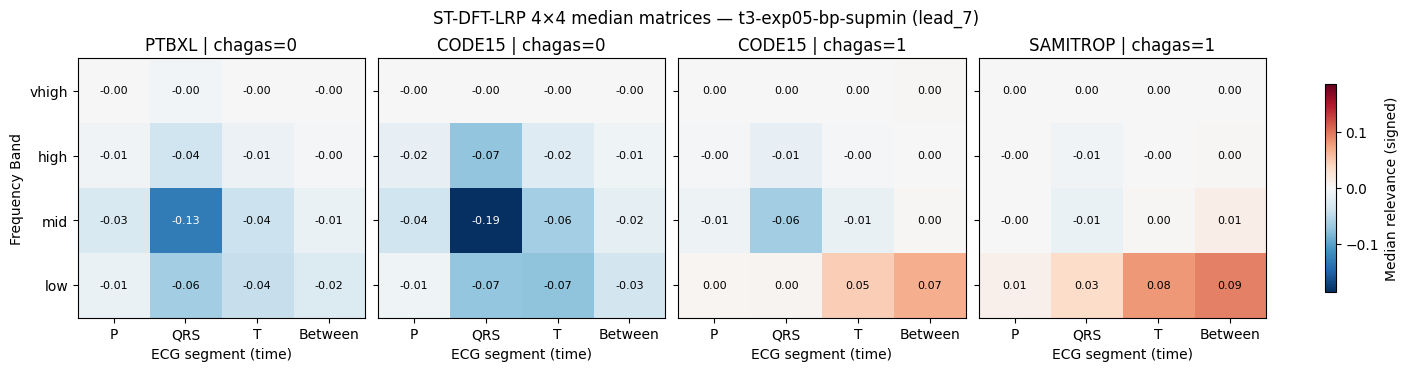

/tmp/ipykernel_436309/212001176.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('RdBu_r')


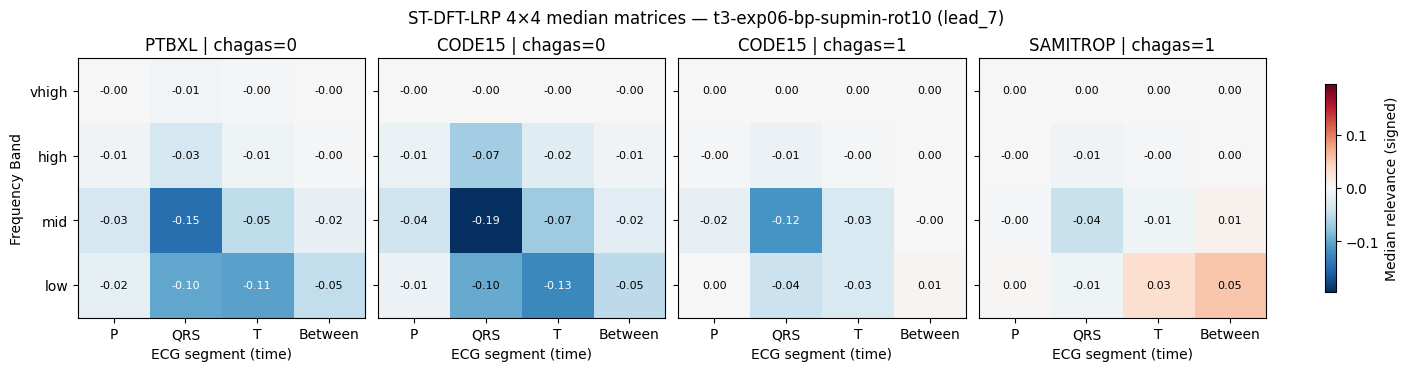

/tmp/ipykernel_436309/212001176.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('RdBu_r')


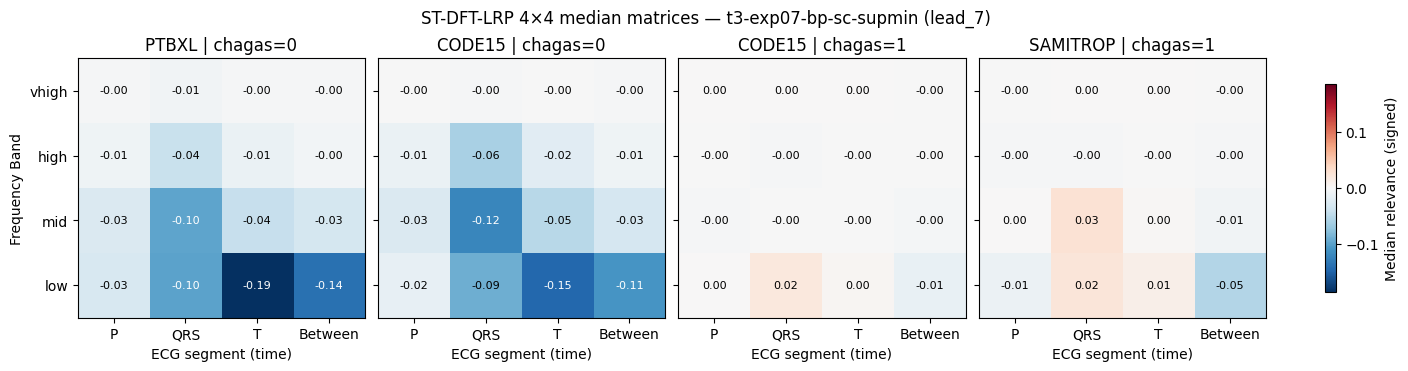

/tmp/ipykernel_436309/212001176.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('RdBu_r')


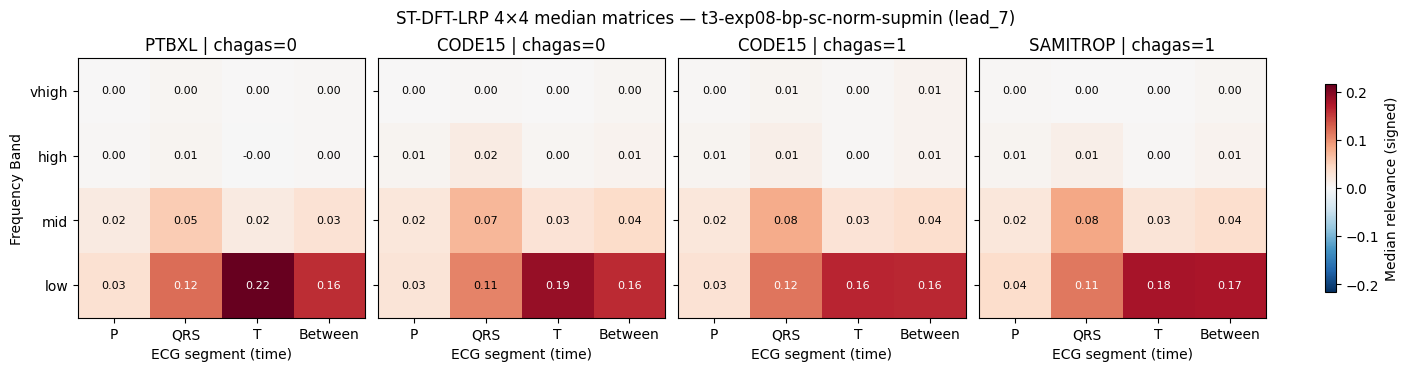

/tmp/ipykernel_436309/212001176.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('RdBu_r')


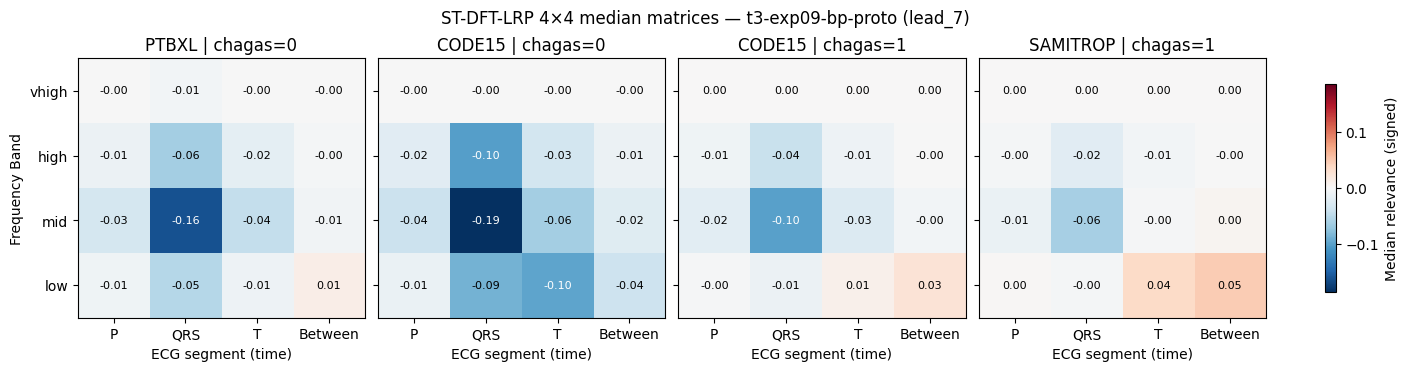

/tmp/ipykernel_436309/212001176.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('RdBu_r')


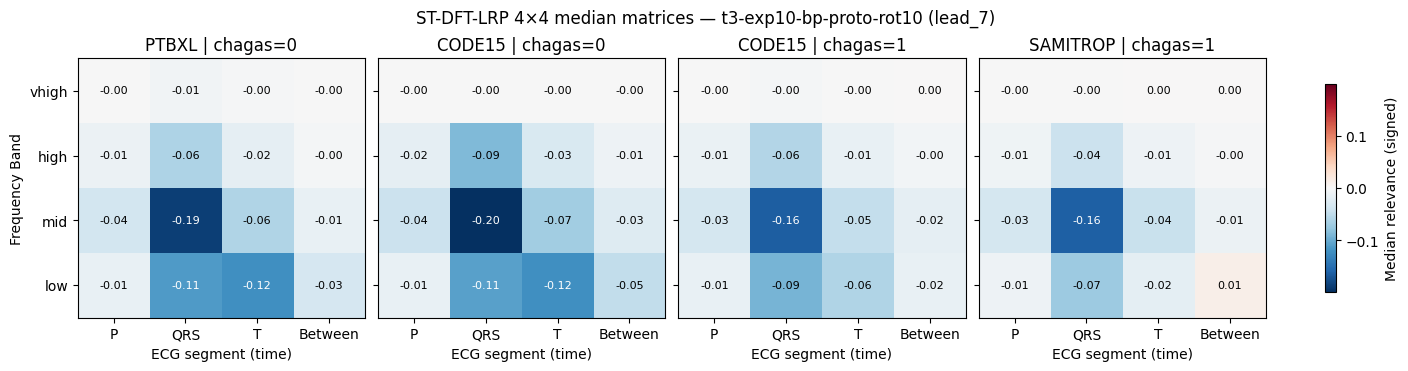

/tmp/ipykernel_436309/212001176.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('RdBu_r')


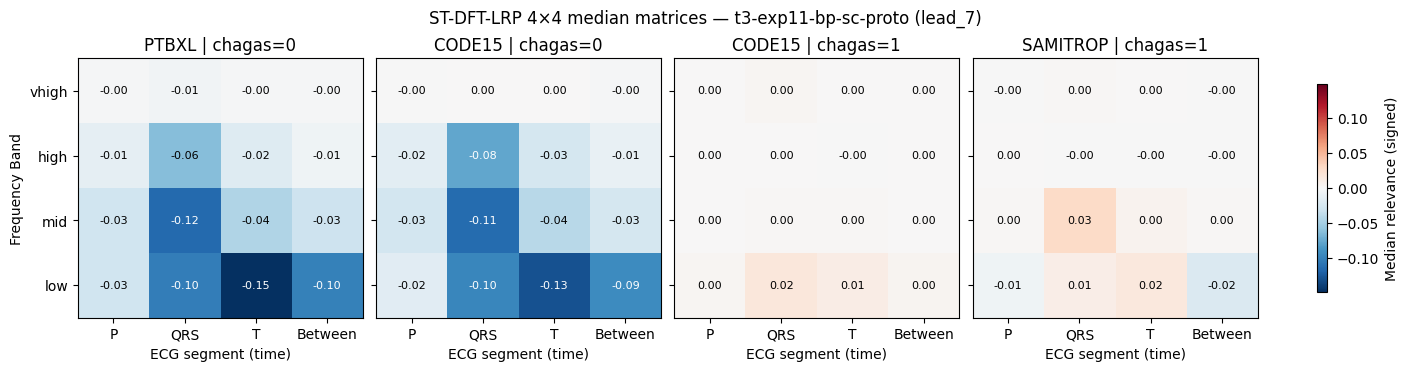

/tmp/ipykernel_436309/212001176.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('RdBu_r')


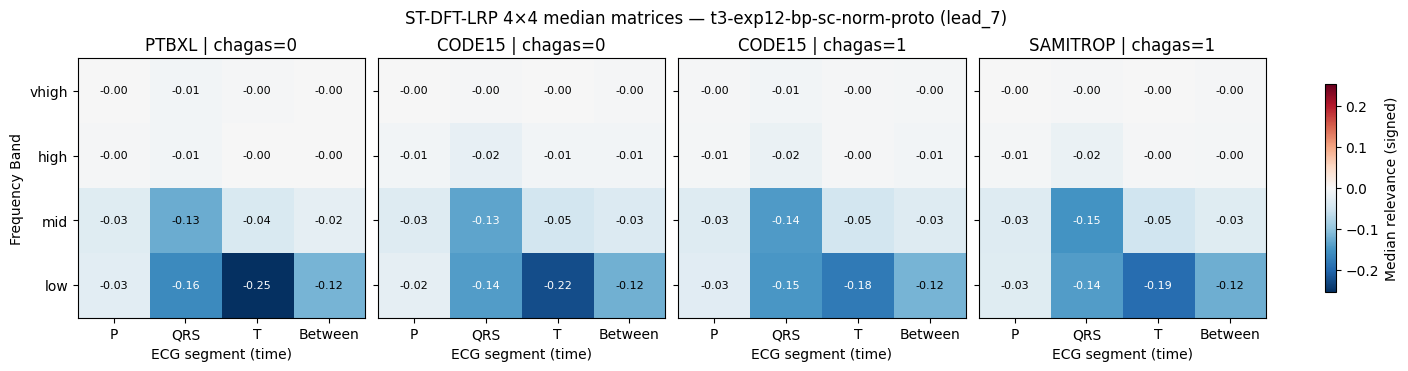

In [20]:
# 4x4 ST-DFT-LRP median heatmaps by dataset x chagas (per model CSV)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

seg_names = ['P', 'QRS', 'T', 'Between']
band_names = ['low', 'mid', 'high', 'vhigh']
rel_cols = [f'rel_weighted_{seg}_{band}' for seg in seg_names for band in band_names]

# Output dir is lead-specific
out_dir = XAI_SUMMARY_DIR

# Iterate per-model CSVs discovered earlier
for path in csv_paths:
    run_id = infer_run_id(path)
    lead_tag = LEAD_TAG
    df_model = pd.read_csv(path)
    df_model.columns = [c.strip() for c in df_model.columns]
    df_model['source'] = df_model['source'].astype(str).str.upper().str.replace('-', '', regex=False).str.replace('%','', regex=False)
    df_model['chagas'] = df_model['chagas'].astype(float).astype(int)

    conditions = [
        ('PTBXL', 0),
        ('CODE15', 0),
        ('CODE15', 1),
        ('SAMITROP', 1),
    ]

    # Compute vmax from median matrices for this model
    median_mats = []
    for src_name, ch_val in conditions:
        sub_tmp = df_model[(df_model['source'] == src_name) & (df_model['chagas'] == ch_val)]
        if sub_tmp.empty:
            continue
        med_tmp = sub_tmp[rel_cols].median().values.reshape(len(seg_names), len(band_names))
        median_mats.append(med_tmp)

    if median_mats:
        abs_max = float(np.nanmax(np.abs(np.stack(median_mats, axis=0))))
    else:
        abs_max = 0.0

    vmax = abs_max if np.isfinite(abs_max) and abs_max > 0 else 1e-6
    cmap = mpl.cm.get_cmap('RdBu_r')
    norm = mpl.colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    band_names_plot = list(reversed(band_names))

    fig, axes = plt.subplots(1, 4, figsize=(14, 3.6), constrained_layout=True, sharey=True)
    ims = []
    for ax, (src, ch) in zip(axes, conditions):
        sub = df_model[(df_model['source'] == src) & (df_model['chagas'] == ch)]
        if sub.empty:
            ax.axis('off')
            ax.set_title(f'{src} | chagas={ch}(no data)')
            continue
        med = sub[rel_cols].median().values.reshape(len(seg_names), len(band_names))
        mat = med.T[::-1, :]

        im = ax.imshow(mat, cmap=cmap, norm=norm, aspect='auto')
        ims.append(im)

        ax.set_title(f'{src} | chagas={ch}')
        ax.set_xlabel('ECG segment (time)')
        ax.set_xticks(range(len(seg_names)))
        ax.set_xticklabels(seg_names)
        ax.set_yticks(range(len(band_names_plot)))
        ax.set_yticklabels(band_names_plot)
        if ax is axes[0]:
            ax.set_ylabel('Frequency Band')
        else:
            ax.set_ylabel('')

        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                r, g, b, _ = cmap(norm(mat[i, j]))
                luminance = 0.299*r + 0.587*g + 0.114*b
                txt_color = 'black' if luminance > 0.6 else 'white'
                ax.text(j, i, f"{mat[i, j]:.2f}", ha='center', va='center', fontsize=8, color=txt_color)

    if ims:
        fig.colorbar(ims[0], ax=axes, location='right', shrink=0.8, label='Median relevance (signed)')

    fig.suptitle(f'ST-DFT-LRP 4×4 median matrices — {run_id} ({lead_tag})', fontsize=12)

    out_path = out_dir / 'plots' / f'stdftlrp_4x4_{run_id}__{lead_tag}.png'
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=200)
    plt.show()


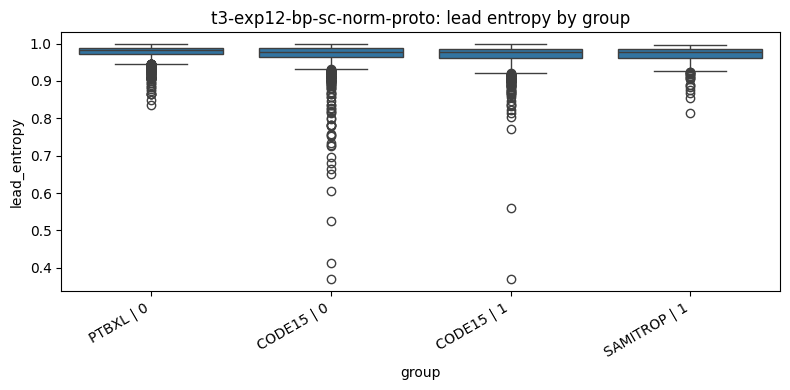

In [21]:
# Lead entropy distribution by group (single model)
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='group', y='lead_entropy')
plt.title(f'{run_id}: lead entropy by group')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


In [22]:
# Build per-run summaries and aggregate across model groups
from ecg_chagas_embeddings.analysis.run_specs import load_run_specs
global_cfg, runs = load_run_specs(root / 'configs/analysis/embeddings_probe_runs.toml')
run_meta = {r.run_id: r for r in runs}

def summarize(df, group_cols=('source','chagas')):
    df = df.copy()
    df['source'] = df['source'].astype(str).str.upper().str.replace('-', '', regex=False).str.replace('%','', regex=False)
    df['group'] = df[group_cols[0]].astype(str)
    for c in group_cols[1:]:
        df['group'] = df['group'] + ' | ' + df[c].astype(str)
    metrics = [c for c in df.columns if c.startswith('p_lead_') or c == 'lead_entropy']
    out = df.groupby('group')[metrics].mean().reset_index()
    return out

summ_rows = []
for p in csv_paths:
    run_id = infer_run_id(p)
    df_r = pd.read_csv(p)
    summ = summarize(df_r)
    meta = run_meta.get(run_id)
    summ.insert(0, 'run_id', run_id)
    summ.insert(1, 'track', str(meta.track) if meta else '')
    summ.insert(2, 'preprocessing', str(meta.preprocessing) if meta else '')
    summ.insert(3, 'loss', str(getattr(meta, 'loss', '')) if meta else '')
    summ_rows.append(summ)

per_run = pd.concat(summ_rows, ignore_index=True)
per_run.head()


,run_id,track,preprocessing,loss,group,lead_entropy,p_lead_0,p_lead_1,p_lead_2,p_lead_3,p_lead_4,p_lead_5,p_lead_6,p_lead_7,p_lead_8,p_lead_9,p_lead_10,p_lead_11
0,t1-exp01-bp-bce,t1,bp,,CODE15 | 0,0.968603,0.074262,0.087784,0.062937,0.067651,0.056677,0.062192,0.084482,0.106708,0.118148,0.095995,0.088986,0.094177
1,t1-exp01-bp-bce,t1,bp,,CODE15 | 1,0.967921,0.072573,0.081587,0.068072,0.061666,0.061810,0.062014,0.094719,0.104472,0.115343,0.096650,0.088995,0.092097
2,t1-exp01-bp-bce,t1,bp,,PTBXL | 0,0.976735,0.077591,0.087814,0.065281,0.069255,0.060159,0.062830,0.086064,0.124136,0.113043,0.092304,0.081592,0.079930
3,t1-exp01-bp-bce,t1,bp,,SAMITROP | 1,0.970038,0.072269,0.084329,0.067020,0.062504,0.060500,0.063078,0.101518,0.105116,0.114311,0.092810,0.084001,0.092545
4,t1-exp02-bp-bce-rot10,t1,bp,,CODE15 | 0,0.965281,0.074177,0.082421,0.058008,0.065685,0.054065,0.059611,0.090506,0.108041,0.124341,0.098503,0.088503,0.096140


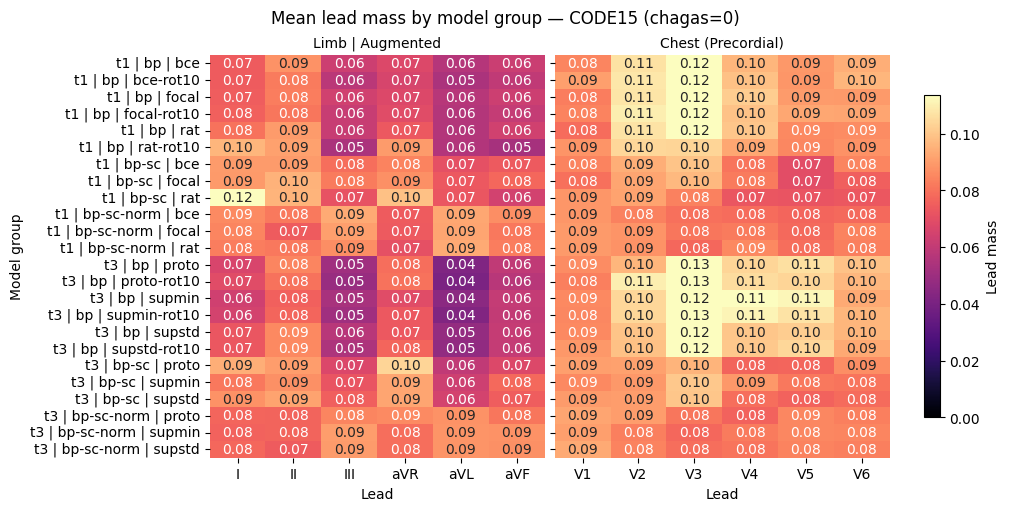

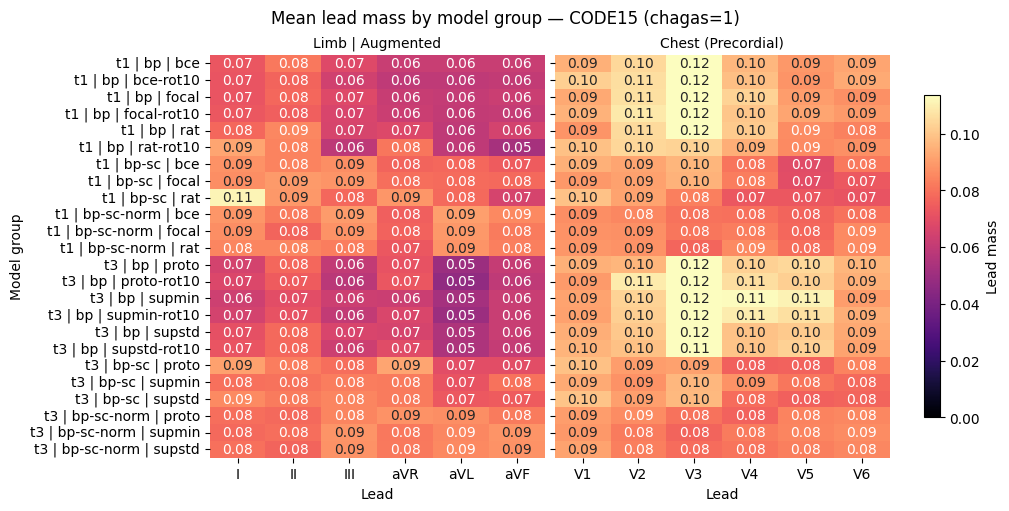

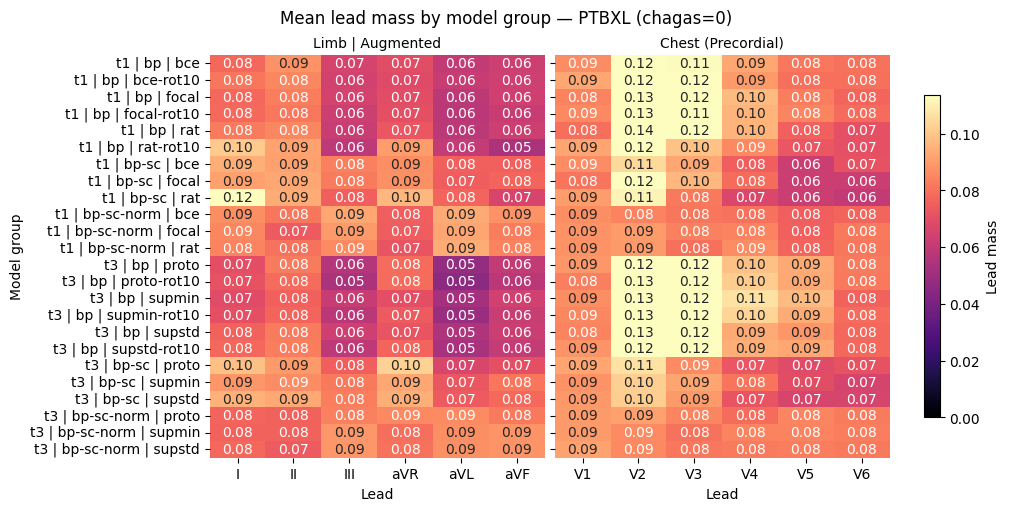

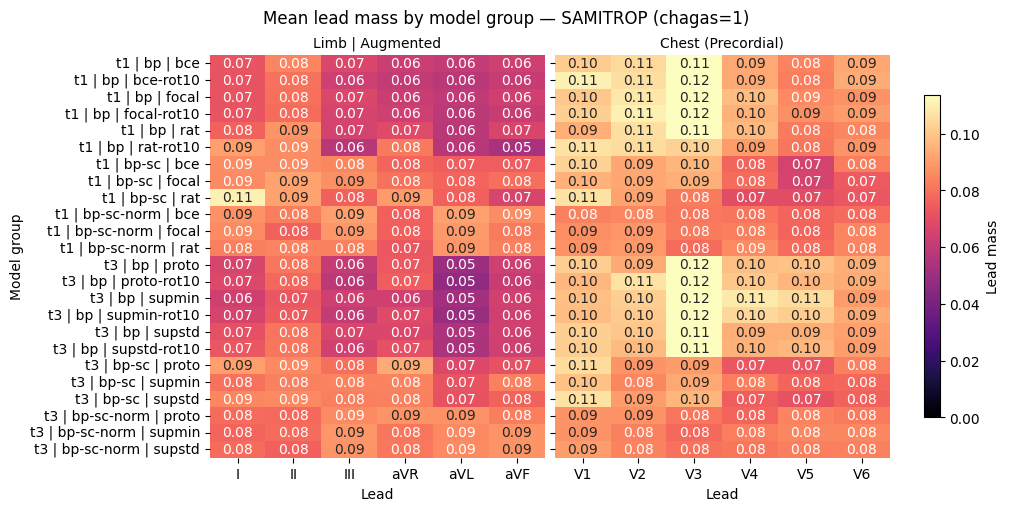

In [23]:
# Mean lead mass by model group for all 4 source×label conditions
# This produces 4 heatmaps + 4 tables (one per condition) and saves them.

conditions = [
    ('CODE15', 0),
    ('CODE15', 1),
    ('PTBXL', 0),
    ('SAMITROP', 1),
]

# Ensure output directory exists (fallback if not defined above)
try:
    out_dir
except NameError:
    from pathlib import Path
    out_dir = XAI_SUMMARY_DIR

sub = per_run.copy()
# Normalize column names (some CSVs include whitespace)
sub.columns = [c.strip() for c in sub.columns]

# Normalize source/chagas if present; otherwise parse from `group`
if 'source' in sub.columns:
    sub['source'] = sub['source'].astype(str).str.upper().str.replace('-', '', regex=False).str.replace('%','', regex=False)
if 'chagas' in sub.columns:
    sub['chagas'] = sub['chagas'].astype(float).astype(int)

if 'source' not in sub.columns or 'chagas' not in sub.columns:
    if 'group' in sub.columns:
        parts = sub['group'].astype(str).str.split(r'\s*\|\s*', n=1, expand=True)
        if 'source' not in sub.columns:
            sub['source'] = parts[0].astype(str).str.upper().str.replace('-', '', regex=False).str.replace('%','', regex=False)
        if 'chagas' not in sub.columns:
            sub['chagas'] = parts[1].astype(str).astype(float).astype(int)

# Ensure run_id is clean
sub['run_id'] = sub['run_id'].astype(str).str.strip()



def parse_model_group(rid: str):
    rid = str(rid)
    track = rid.split('-', 1)[0] if '-' in rid else rid
    preproc = 'bp'
    if 'bp-sc-norm' in rid:
        preproc = 'bp-sc-norm'
    elif 'bp-sc' in rid:
        preproc = 'bp-sc'
    elif 'bp' in rid:
        preproc = 'bp'
    loss = None
    for cand in ['bce','focal','rat','supstd','supmin','proto']:
        if f'-{cand}' in rid:
            loss = cand
            break
    if loss is None:
        loss = 'unknown'
    axisrot_tag = '-rot10' if 'rot10' in rid else ''
    return track, preproc, loss, axisrot_tag

# Parse model metadata from run_id
sub[['track','preproc','loss','axisrot_tag']] = sub['run_id'].apply(parse_model_group).apply(pd.Series)
sub['model_group'] = (
    sub['track'] + ' | ' + sub['preproc'] + ' | ' + sub['loss'] + sub['axisrot_tag']
)

lead_cols = [c for c in sub.columns if c.startswith('p_lead_')]
lead_order = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']

# Global vmax across all conditions for a shared scale
vmax = float(np.quantile(sub[lead_cols].to_numpy().ravel(), 0.95))

lead_groups = {
    'Limb | Augmented': ['I','II','III','aVR','aVL','aVF'],
    'Chest (Precordial)': ['V1','V2','V3','V4','V5','V6'],
}

for source, ch in conditions:
    target = sub[(sub['source'] == source) & (sub['chagas'] == ch)].copy()
    if target.empty:
        print(f"No rows for target_group='{source} | {ch}'. Try a different group.")
        continue

    # Aggregate by model group
    group_means = target.groupby('model_group')[lead_cols].mean()
    group_means = group_means.reindex(sorted(group_means.index))
    group_means.columns = lead_order

    # Save table
    out_table = out_dir / f'lead_mass_table_{source}_{ch}.csv'
    out_table.parent.mkdir(parents=True, exist_ok=True)
    group_means.to_csv(out_table)

    # Split into lead groups for clean labels
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True, constrained_layout=True)
    for ax, (gname, cols) in zip(axes, lead_groups.items()):
        submat = group_means[cols]
        sns.heatmap(submat, ax=ax, cmap='magma', vmin=0, vmax=vmax, cbar=False, annot=True, fmt='.2f')
        ax.set_title(gname, fontsize=10)
        ax.set_xlabel('Lead')
        if ax is axes[0]:
            ax.set_ylabel('Model group')
        else:
            ax.set_ylabel('')

    # single shared colorbar
    mappable = axes[0].collections[0]
    fig.colorbar(mappable, ax=axes, location='right', shrink=0.8, label='Lead mass')
    fig.suptitle(f'Mean lead mass by model group — {source} (chagas={ch})', fontsize=12)

    out_path = out_dir / 'plots' / f'lead_mass_heatmap_{source}_{ch}.png'
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=200)
    plt.show()


In [24]:
# Compact preprocessing summary: limb vs precordial share
from IPython.display import display

# Build preprocessing means if not already present
lead_cols = [c for c in sub.columns if c.startswith('p_lead_')]
lead_order = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']

preproc_means = sub.groupby('preproc')[lead_cols].mean()
preproc_means = preproc_means.reindex(['bp','bp-sc','bp-sc-norm']).dropna(how='all')
preproc_means.columns = lead_order

lead_limb = ['I','II','III','aVR','aVL','aVF']
lead_prec = ['V1','V2','V3','V4','V5','V6']

preproc_tbl = pd.DataFrame({
    'limb_share': preproc_means[lead_limb].sum(axis=1),
    'precordial_share': preproc_means[lead_prec].sum(axis=1),
})
preproc_tbl['precordial_to_limb'] = preproc_tbl['precordial_share'] / preproc_tbl['limb_share']

print('Limb vs Precordial share by preprocessing regime')
display(preproc_tbl)

# Save for LaTeX
out_dir = XAI_SUMMARY_DIR
out_dir.mkdir(parents=True, exist_ok=True)
out_table = out_dir / 'preproc_lead_share_table.csv'
preproc_tbl.to_csv(out_table)


Limb vs Precordial share by preprocessing regime


,limb_share,precordial_share,precordial_to_limb
preproc,,,
bp,0.401250,0.598750,1.492214
bp-sc,0.495951,0.504049,1.016329
bp-sc-norm,0.499740,0.500260,1.001039


## Quantitative 4×4 ST-DFT-LRP analysis (shares and deltas)



This block computes per-model share summaries from the 4×4 matrices (using absolute mass proxy `abs(rel_weighted)`), then derives within-model deltas for disease and dataset effects. Outputs are written per selected `LEAD_TAG`.



In [25]:
# Compute per-model shares and deltas from 4x4 matrices
import re
import numpy as np
import pandas as pd

EPS = 1e-12
seg_names = ['P', 'QRS', 'T', 'Between']
band_names = ['low', 'mid', 'high', 'vhigh']
rel_cols = [f'rel_weighted_{seg}_{band}' for seg in seg_names for band in band_names]

# Ensure essentials exist
if 'csv_paths' not in locals() or not csv_paths:
    RUNS_DIR = root / 'analysis' / 'embeddings_probe' / 'runs'
    csv_paths = sorted(RUNS_DIR.glob(f'*/xai/{LEAD_TAG}/stdftlrp_beat_agg.csv'))


def _infer_run_id(path):
    parts = list(path.parts)
    if 'runs' in parts:
        i = parts.index('runs')
        if i + 1 < len(parts):
            return parts[i + 1]
    return path.parent.name


def parse_model_group(rid: str):
    rid = str(rid)
    m_track = re.search(r'^(t\d+)', rid)
    m_exp = re.search(r'exp(\\d+)', rid)
    track = m_track.group(1) if m_track else ''
    exp_n = int(m_exp.group(1)) if m_exp else 999
    if 'bp-sc-norm' in rid:
        preproc = 'bp-sc-norm'
    elif 'bp-sc' in rid:
        preproc = 'bp-sc'
    elif 'bp' in rid:
        preproc = 'bp'
    else:
        preproc = 'unknown'
    loss = 'unknown'
    for cand in ['bce', 'focal', 'rat', 'supstd', 'supmin', 'proto']:
        if f'-{cand}' in rid:
            loss = cand
            break
    axisrot = 'rot10' in rid
    return track, exp_n, preproc, loss, axisrot


share_rows = []
for path in csv_paths:
    run_id = _infer_run_id(path)
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    if not set(rel_cols).issubset(df.columns):
        continue

    df['source'] = (
        df['source'].astype(str)
        .str.upper()
        .str.replace('-', '', regex=False)
        .str.replace('%', '', regex=False)
        .str.strip()
    )
    df['chagas'] = df['chagas'].astype(float).astype(int)

    for (src, ch), g in df.groupby(['source', 'chagas'], dropna=False):
        if g.empty:
            continue

        med_vec = g[rel_cols].median().to_numpy(dtype=float)
        # reshape as [segment, band] then convert to [band, segment]
        mat_seg_band = med_vec.reshape(len(seg_names), len(band_names))
        mat_band_seg = mat_seg_band.T

        # Absolute-mass proxy for location shares
        M = np.abs(mat_band_seg)
        T = float(np.nansum(M)) + EPS
        band_share = np.nansum(M, axis=1) / T  # low..vhigh
        seg_share = np.nansum(M, axis=0) / T   # P..Between

        # Optional scalars
        physio_ratio = float((seg_share[0] + seg_share[1] + seg_share[2]) / (seg_share[3] + EPS))
        signed_total = float(np.nansum(mat_band_seg))
        abs_total = float(np.nansum(np.abs(mat_band_seg))) + EPS
        polarity = signed_total / abs_total

        track, exp_n, preproc, loss, axisrot = parse_model_group(run_id)

        row = {
            'run_id': run_id,
            'track': track,
            'exp_n': exp_n,
            'preprocessing': preproc,
            'loss': loss,
            'axisrot': axisrot,
            'lead_tag': LEAD_TAG,
            'source': src,
            'chagas': int(ch),
            'n_group_samples': int(len(g)),
            'physio_ratio': physio_ratio,
            'polarity': float(polarity),
        }
        for i, b in enumerate(band_names):
            row[f'band_{b}'] = float(band_share[i])
        for j, s in enumerate(seg_names):
            row[f'seg_{s}'] = float(seg_share[j])
        share_rows.append(row)

shares_df = pd.DataFrame(share_rows)
if shares_df.empty:
    raise ValueError(f'No valid share rows computed for {LEAD_TAG}.')

# Stable model sorting
track_order = {'t1': 0, 't2': 1, 't3': 2}
preproc_order = {'bp': 0, 'bp-sc': 1, 'bp-sc-norm': 2}
shares_df['_track_o'] = shares_df['track'].map(track_order).fillna(9)
shares_df['_prep_o'] = shares_df['preprocessing'].map(preproc_order).fillna(9)
shares_df = shares_df.sort_values(['_track_o', '_prep_o', 'exp_n', 'loss', 'axisrot', 'run_id', 'source', 'chagas']).drop(columns=['_track_o', '_prep_o'])

# Deltas per model
vec_cols = [f'band_{b}' for b in band_names] + [f'seg_{s}' for s in seg_names] + ['physio_ratio', 'polarity']


def _get_group_row(dfm, src, ch):
    m = (dfm['source'] == src) & (dfm['chagas'] == ch)
    if not m.any():
        return None
    return dfm.loc[m].iloc[0]


delta_rows = []
for run_id, dfm in shares_df.groupby('run_id'):
    base = dfm.iloc[0]
    r_c15_0 = _get_group_row(dfm, 'CODE15', 0)
    r_c15_1 = _get_group_row(dfm, 'CODE15', 1)
    r_ptb_0 = _get_group_row(dfm, 'PTBXL', 0)
    r_sam_1 = _get_group_row(dfm, 'SAMITROP', 1)

    contrasts = {
        'delta_disease_code15': (r_c15_1, r_c15_0),
        'delta_dataset_neg': (r_ptb_0, r_c15_0),
        'delta_dataset_pos': (r_sam_1, r_c15_1),
    }

    for delta_name, (a, b) in contrasts.items():
        row = {
            'run_id': run_id,
            'track': base['track'],
            'exp_n': int(base['exp_n']),
            'preprocessing': base['preprocessing'],
            'loss': base['loss'],
            'axisrot': bool(base['axisrot']),
            'lead_tag': LEAD_TAG,
            'delta_type': delta_name,
        }
        for c in vec_cols:
            row[c] = float(a[c] - b[c]) if (a is not None and b is not None) else np.nan
        delta_rows.append(row)

deltas_df = pd.DataFrame(delta_rows)

# Save outputs
out_dir = XAI_SUMMARY_DIR
out_dir.mkdir(parents=True, exist_ok=True)
shares_path = out_dir / 'stdftlrp_v2_shares.csv'
deltas_path = out_dir / 'stdftlrp_v2_deltas.csv'
shares_df.to_csv(shares_path, index=False)
deltas_df.to_csv(deltas_path, index=False)
print('Wrote', shares_path)
print('Wrote', deltas_path)
print('shares shape:', shares_df.shape, 'deltas shape:', deltas_df.shape)
shares_df.head(3)


Wrote /home/flo178/projects/master-thesis/ecg-chagas-embeddings/analysis/embeddings_probe/xai_summary/lead_7/stdftlrp_v2_shares.csv
Wrote /home/flo178/projects/master-thesis/ecg-chagas-embeddings/analysis/embeddings_probe/xai_summary/lead_7/stdftlrp_v2_deltas.csv
shares shape: (96, 20) deltas shape: (72, 18)


,run_id,track,exp_n,preprocessing,loss,axisrot,lead_tag,source,chagas,n_group_samples,physio_ratio,polarity,band_low,band_mid,band_high,band_vhigh,seg_P,seg_QRS,seg_T,seg_Between
0,t1-exp01-bp-bce,t1,999,bp,bce,False,lead_7,CODE15,0,1621,1.768221,1.000000,0.705507,0.210942,0.060124,0.023427,0.070506,0.224617,0.343634,0.361243
1,t1-exp01-bp-bce,t1,999,bp,bce,False,lead_7,CODE15,1,1296,2.300743,1.000000,0.630113,0.269317,0.068215,0.032355,0.094874,0.308449,0.293715,0.302962
2,t1-exp01-bp-bce,t1,999,bp,bce,False,lead_7,PTBXL,0,1596,10.223154,-0.695715,0.341075,0.499411,0.127329,0.032185,0.162543,0.534647,0.213709,0.089102


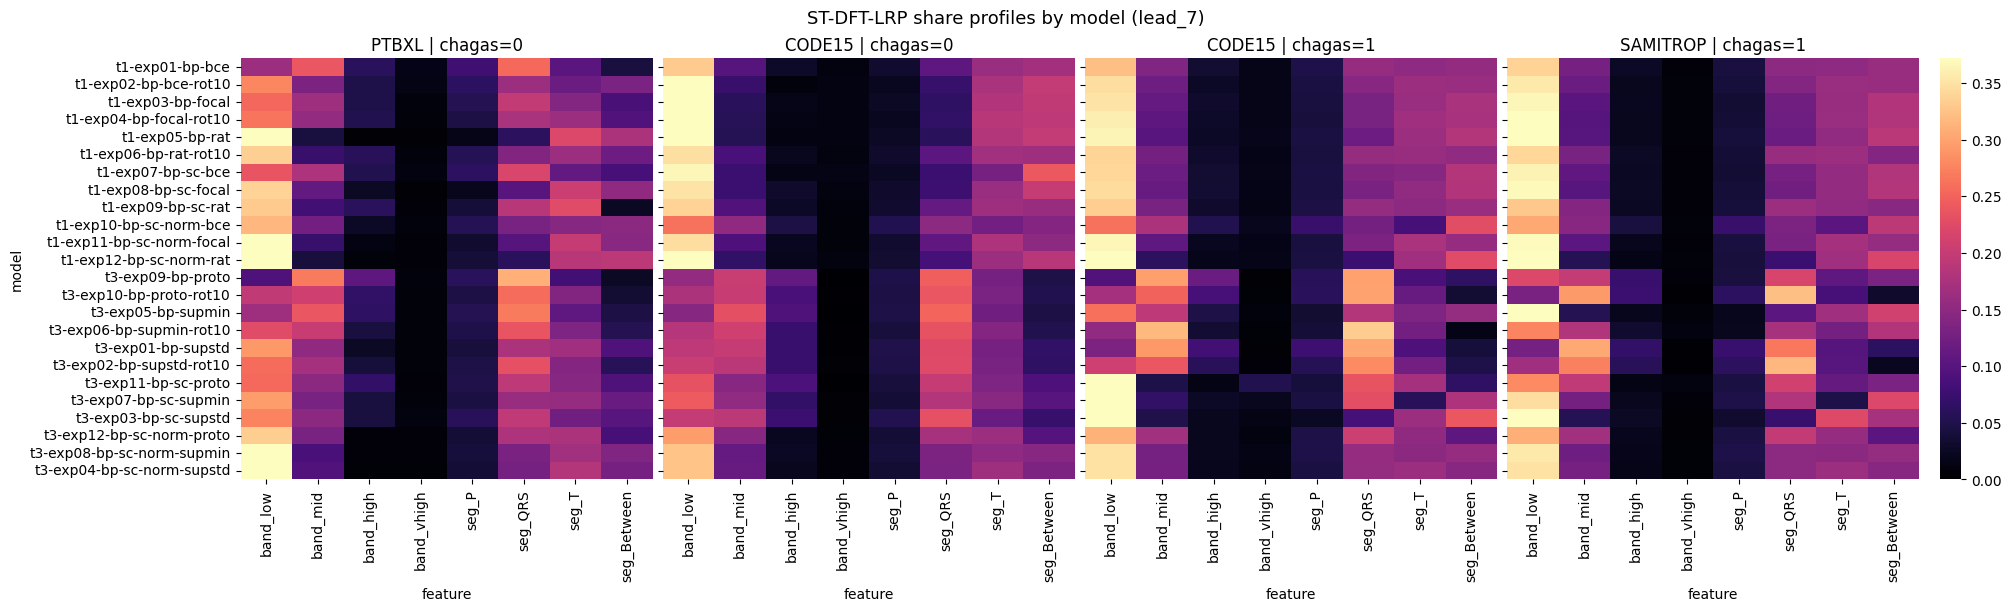

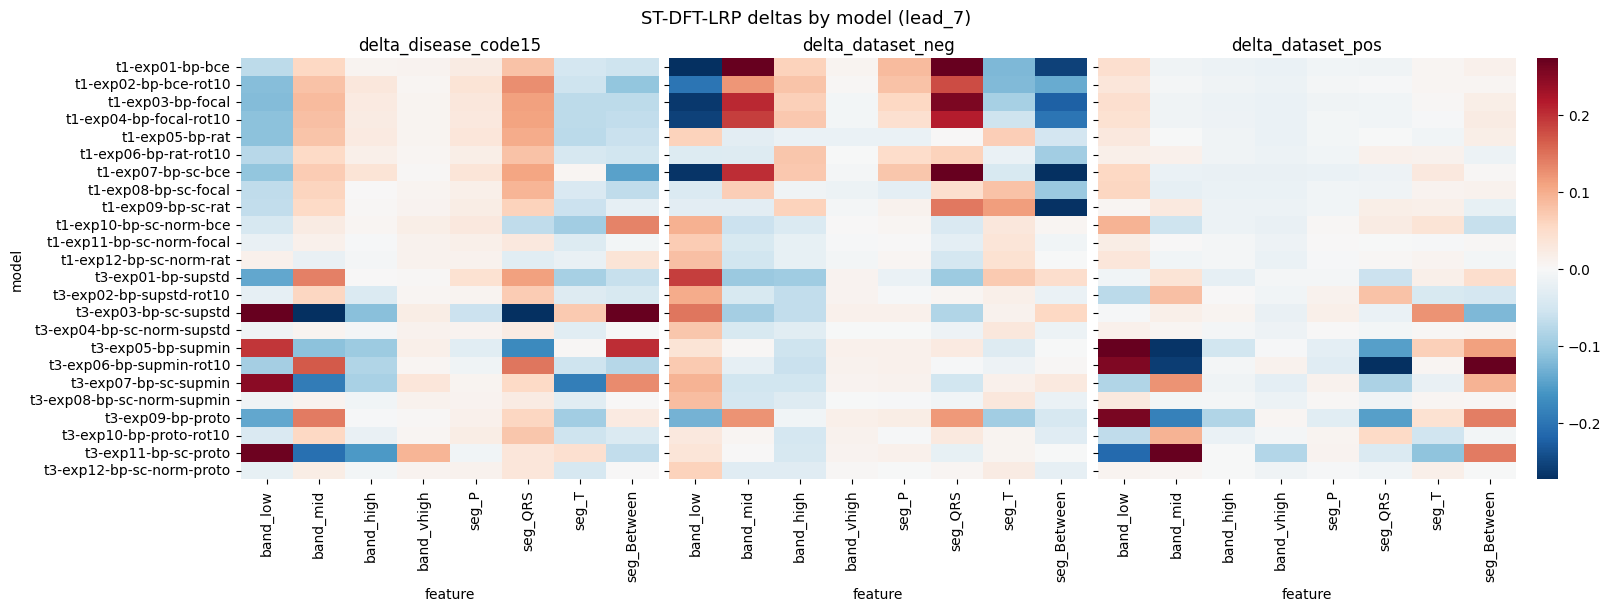

Median deltas by preprocessing (seg_Between, physio_ratio)


,preprocessing,delta_type,seg_Between,physio_ratio
0,bp,delta_dataset_neg,-0.050465,1.202710
1,bp,delta_dataset_pos,0.018970,-0.152250
2,bp,delta_disease_code15,-0.061134,0.524085
3,bp-sc,delta_dataset_neg,-0.053819,0.394910
4,bp-sc,delta_dataset_pos,0.007316,-0.055932
5,bp-sc,delta_disease_code15,-0.047220,0.352177
6,bp-sc-norm,delta_dataset_neg,-0.012946,0.155242
7,bp-sc-norm,delta_dataset_pos,0.000651,0.002268
8,bp-sc-norm,delta_disease_code15,0.001125,-0.019340


In [26]:
# Plot: model x feature heatmaps (shares and deltas) + preprocessing summary
import seaborn as sns
import matplotlib.pyplot as plt

feature_cols = [f'band_{b}' for b in band_names] + [f'seg_{s}' for s in seg_names]

# ---- Shares heatmaps by group ----
groups_to_plot = [('PTBXL',0), ('CODE15',0), ('CODE15',1), ('SAMITROP',1)]
fig, axes = plt.subplots(1, 4, figsize=(20, 6), constrained_layout=True, sharey=True)
for ax, (src, ch) in zip(axes, groups_to_plot):
    subg = shares_df[(shares_df['source']==src) & (shares_df['chagas']==ch)].copy()
    if subg.empty:
        ax.axis('off')
        ax.set_title(f'{src} | {ch} (no data)')
        continue
    hm = subg.set_index('run_id')[feature_cols]
    # row-wise normalization to compare profiles instead of absolute shifts
    hm_norm = hm.div(hm.sum(axis=1).replace(0, np.nan), axis=0)
    sns.heatmap(hm_norm, cmap='magma', ax=ax, cbar=(ax is axes[-1]), vmin=0, vmax=np.nanquantile(hm_norm.to_numpy(), 0.98))
    ax.set_title(f'{src} | chagas={ch}')
    ax.set_xlabel('feature')
    if ax is axes[0]:
        ax.set_ylabel('model')
    else:
        ax.set_ylabel('')
fig.suptitle(f'ST-DFT-LRP share profiles by model ({LEAD_TAG})', fontsize=13)
plt.show()

# ---- Delta heatmaps ----
delta_types = ['delta_disease_code15', 'delta_dataset_neg', 'delta_dataset_pos']
fig, axes = plt.subplots(1, 3, figsize=(16, 6), constrained_layout=True, sharey=True)
for ax, dt in zip(axes, delta_types):
    subd = deltas_df[deltas_df['delta_type']==dt].copy()
    if subd.empty:
        ax.axis('off')
        ax.set_title(f'{dt} (no data)')
        continue
    hm = subd.set_index('run_id')[feature_cols]
    vmax = np.nanquantile(np.abs(hm.to_numpy()), 0.98)
    vmax = float(vmax) if np.isfinite(vmax) and vmax > 0 else 1e-6
    sns.heatmap(hm, cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax, ax=ax, cbar=(ax is axes[-1]))
    ax.set_title(dt)
    ax.set_xlabel('feature')
    if ax is axes[0]:
        ax.set_ylabel('model')
    else:
        ax.set_ylabel('')
fig.suptitle(f'ST-DFT-LRP deltas by model ({LEAD_TAG})', fontsize=13)
plt.show()

# ---- Preprocessing summary for key scalars ----
summary = (
    deltas_df.groupby(['preprocessing','delta_type'])[['seg_Between','physio_ratio']]
    .median()
    .reset_index()
)
print('Median deltas by preprocessing (seg_Between, physio_ratio)')
display(summary)
